In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ---------------------------------------------------------
# 1. PARÂMETROS E PROPRIEDADES (Unidades: kN, mm)
# ---------------------------------------------------------
E = 200.0  # Módulo de Elasticidade em kN/mm² (200000 MPa)

# Momentos de Inércia (mm^4) calculados previamente
I_A = 1653007211.6245 
I_B = 334482563.4911 

# Coordenadas dos nós ao longo do eixo X (mm)
nos = np.array([0, 400, 800, 1200, 1600, 2600, 3000, 3400, 3800, 4200], dtype=float)
n_nos = len(nos)
n_gl = n_nos * 2  # 2 Graus de Liberdade por nó (deslocamento vertical v, rotação theta)

# Definição dos elementos: [no_i, no_j, Inercia_do_elemento]
elementos = [
    [0, 1, I_A],  # Tramo A
    [1, 2, I_A],  # Tramo A
    [2, 3, I_A],  # Tramo A
    [3, 4, I_A],  # Tramo A
    [4, 5, I_B],  # Tramo B (Central)
    [5, 6, I_A],  # Tramo A
    [6, 7, I_A],  # Tramo A
    [7, 8, I_A],  # Tramo A
    [8, 9, I_A]   # Tramo A
]

# ---------------------------------------------------------
# 2. MONTAGEM DA MATRIZ DE RIGIDEZ GLOBAL E VETOR DE FORÇAS
# ---------------------------------------------------------
K_global = np.zeros((n_gl, n_gl))
F_global = np.zeros(n_gl)

# Matriz de rigidez do elemento de viga Euler-Bernoulli
def matriz_rigidez_viga(E, I, L):
    return (E * I / L**3) * np.array([
        [12,   6*L,     -12,  6*L],
        [6*L,  4*L**2,  -6*L, 2*L**2],
        [-12, -6*L,      12, -6*L],
        [6*L,  2*L**2,  -6*L, 4*L**2]
    ])

for el in elementos:
    no_i, no_j, I_el = el
    L = nos[no_j] - nos[no_i]
    K_el = matriz_rigidez_viga(E, I_el, L)
    
    gls = [2*no_i, 2*no_i+1, 2*no_j, 2*no_j+1]
    
    for i in range(4):
        for j in range(4):
            K_global[gls[i], gls[j]] += K_el[i, j]

# Aplicação das cargas pontuais de 30 kN (para baixo, portanto negativas)
nos_com_carga = [1, 2, 3, 6, 7, 8]
for no in nos_com_carga:
    F_global[2 * no] = -30.0

# ---------------------------------------------------------
# 3. CONDIÇÕES DE CONTORNO E SOLUÇÃO
# ---------------------------------------------------------
gls_restritos = [0, 18] # Nós 0 e 9 restritos na vertical
gls_livres = [i for i in range(n_gl) if i not in gls_restritos]

K_red = K_global[np.ix_(gls_livres, gls_livres)]
F_red = F_global[gls_livres]

D_red = np.linalg.solve(K_red, F_red)

D_global = np.zeros(n_gl)
D_global[gls_livres] = D_red

# ---------------------------------------------------------
# 4. CÁLCULO DE REAÇÕES E ESFORÇOS INTERNOS
# ---------------------------------------------------------
# Reações de apoio
F_reacoes = K_global.dot(D_global)
R_esq = F_reacoes[0]
R_dir = F_reacoes[18]

# Esforços Internos para Diagramas (Cortante e Momento)
V_elems = []
X_m = []
M_z = []

for el in elementos:
    no_i, no_j, I_el = el
    L = nos[no_j] - nos[no_i]
    K_el = matriz_rigidez_viga(E, I_el, L)
    gls = [2*no_i, 2*no_i+1, 2*no_j, 2*no_j+1]
    d_el = D_global[gls]
    f_el = K_el.dot(d_el)
    
    # f_el = [Vy_i, Mz_i, Vy_j, Mz_j]
    V_elems.append(f_el[0])
    
    X_m.extend([nos[no_i], nos[no_j]])
    M_z.extend([-f_el[1], f_el[3]]) # Convenção: Momento que traciona fibra inferior é positivo

# Ajuste do Cortante para plotagem em degraus
V_elems.append(V_elems[-1]) # Repete o último valor para fechar o degrau final

=== RESULTADOS DA ANÁLISE ===
Reação Apoio Esq (Ry): 90.00 kN
Reação Apoio Dir (Ry): 90.00 kN

Nó 0 (x = 0 mm):
  Deslocamento (v) = 0.00000 mm
  Rotação (theta)  = -7.84968e-04 rad
Nó 1 (x = 400 mm):
  Deslocamento (v) = -0.31108 mm
  Rotação (theta)  = -7.63189e-04 rad
Nó 2 (x = 800 mm):
  Deslocamento (v) = -0.60571 mm
  Rotação (theta)  = -7.05113e-04 rad
Nó 3 (x = 1200 mm):
  Deslocamento (v) = -0.87227 mm
  Rotação (theta)  = -6.25259e-04 rad
Nó 4 (x = 1600 mm):
  Deslocamento (v) = -1.10495 mm
  Rotação (theta)  = -5.38145e-04 rad
Nó 5 (x = 2600 mm):
  Deslocamento (v) = -1.10495 mm
  Rotação (theta)  = 5.38145e-04 rad
Nó 6 (x = 3000 mm):
  Deslocamento (v) = -0.87227 mm
  Rotação (theta)  = 6.25259e-04 rad
Nó 7 (x = 3400 mm):
  Deslocamento (v) = -0.60571 mm
  Rotação (theta)  = 7.05113e-04 rad
Nó 8 (x = 3800 mm):
  Deslocamento (v) = -0.31108 mm
  Rotação (theta)  = 7.63189e-04 rad
Nó 9 (x = 4200 mm):
  Deslocamento (v) = 0.00000 mm
  Rotação (theta)  = 7.84968e-04 rad
-> Defl

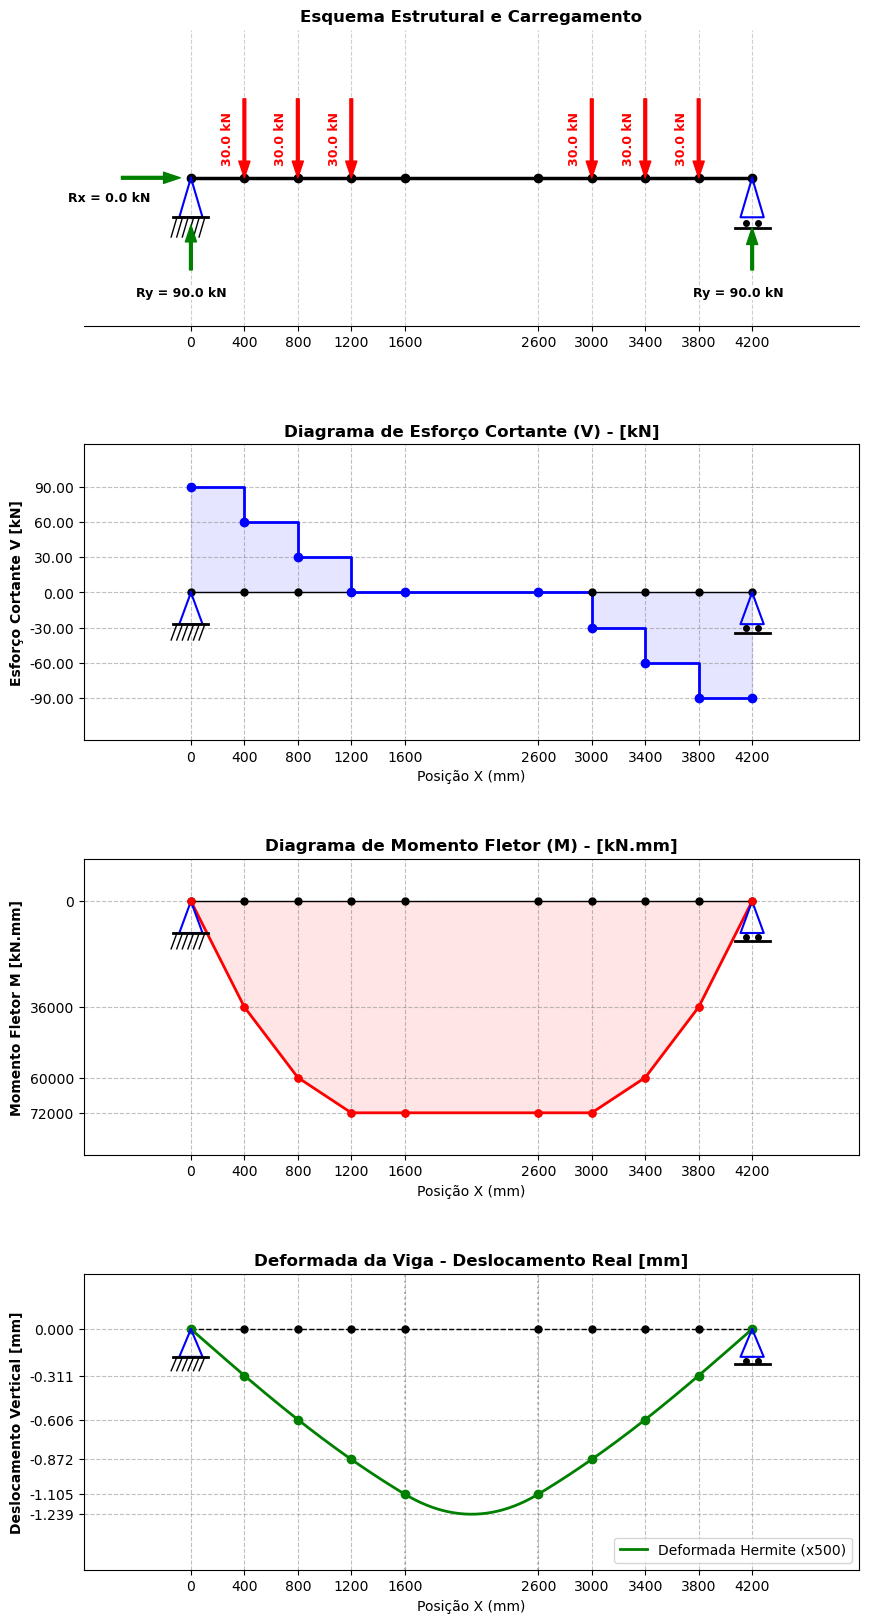

In [2]:
# ---------------------------------------------------------
# 5. FUNÇÕES DE DESENHO DE APOIOS E FORMATAÇÃO 
# ---------------------------------------------------------
def desenhar_apoio_2_ordem(ax, x, y_base, dy, dx):
    h = dy * 0.15
    w = dx * 0.015

    ax.plot([x, x-w, x+w, x],
            [y_base, y_base-h, y_base-h, y_base],
            'b-', lw=1.5, zorder=5, clip_on=False)

    ax.plot([x-w*1.5, x+w*1.5],
            [y_base-h, y_base-h],
            'k-', lw=2, zorder=5, clip_on=False)

    for i in np.linspace(-w*1.2, w*1.2, 6):
        ax.plot([x+i, x+i-w*0.5],
                [y_base-h, y_base-h*1.5],
                'k-', lw=1, zorder=5, clip_on=False)

    return h, w

def desenhar_apoio_1_ordem(ax, x, y_base, dy, dx):
    h = dy * 0.15
    w = dx * 0.015
    gap = dy * 0.04

    ax.plot([x, x-w, x+w, x],
            [y_base, y_base-h, y_base-h, y_base],
            'b-', lw=1.5, zorder=5, clip_on=False)

    ax.plot([x-w*1.5, x+w*1.5],
            [y_base-h-gap, y_base-h-gap],
            'k-', lw=2, zorder=5, clip_on=False)

    ax.plot(x-w*0.5, y_base-h-gap/2,
            'ko', markersize=4, zorder=5, clip_on=False)

    ax.plot(x+w*0.5, y_base-h-gap/2,
            'ko', markersize=4, zorder=5, clip_on=False)

    return h, w, gap

def aplicar_grid_e_limites(ax, data_y, padding_factor=0.2):
    vals = np.array(data_y)
    unique_vals = np.unique(np.round(vals, 2))

    if 0.0 not in unique_vals:
        unique_vals = np.append(unique_vals, 0.0)

    unique_vals = np.sort(unique_vals)

    ax.set_yticks(unique_vals)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

    y_min, y_max = unique_vals.min(), unique_vals.max()
    pad = (y_max - y_min) * padding_factor

    if pad == 0:
        pad = 10

    ax.set_ylim(y_min - pad, y_max + pad)
    ax.grid(True, linestyle='--', color='gray', alpha=0.5)

# ---------------------------------------------------------
# 6. EXIBIÇÃO DE RESULTADOS E GRÁFICOS
# ---------------------------------------------------------
deslocamentos_verticais = D_global[0::2]
rotacoes = D_global[1::2]

print("=== RESULTADOS DA ANÁLISE ===")
print(f"Reação Apoio Esq (Ry): {R_esq:.2f} kN")
print(f"Reação Apoio Dir (Ry): {R_dir:.2f} kN\n")

for i in range(n_nos):
    print(f"Nó {i} (x = {nos[i]:.0f} mm):")
    print(f"  Deslocamento (v) = {deslocamentos_verticais[i]:.5f} mm")
    print(f"  Rotação (theta)  = {rotacoes[i]:.5e} rad")

fig, axs = plt.subplots(4, 1, figsize=(10, 20),
                        gridspec_kw={'hspace': 0.4})

# =========================================================
# GRÁFICO 0: ESQUEMA ESTRUTURAL
# =========================================================
y_span_0 = 40.0

# Estrutura
axs[0].plot([0, nos[-1]], [0, 0],
            'k-', lw=2.5, zorder=2)

# Nós
axs[0].plot(nos, np.zeros(n_nos),
            'ko', markersize=6, zorder=4)

# Cargas
for no in nos_com_carga:
    x_val = nos[no]

    axs[0].annotate(
        "",
        xy=(x_val, 0),
        xytext=(x_val, y_span_0*0.6),
        arrowprops=dict(
            facecolor='red',
            edgecolor='red',
            width=2,
            headwidth=8
        ),
        zorder=10
    )

    axs[0].text(
        x_val - 80,
        y_span_0*0.3,
        "30.0 kN",
        rotation=90,
        ha='right',
        va='center',
        color='red',
        fontweight='bold',
        fontsize=9,
        zorder=10
    )

axs[0].set_xlim(-800, 5000)
axs[0].set_ylim(-45, 45)

axs[0].yaxis.set_visible(False)

axs[0].spines['left'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[0].spines['top'].set_visible(False)

axs[0].set_xticks(nos)
axs[0].xaxis.grid(True, linestyle='--', alpha=0.6)

dy_g0 = 2 * y_span_0
dx_g0 = 5800

h_esq, w_esq = desenhar_apoio_2_ordem(axs[0], 0, 0, dy_g0, dx_g0)
h_dir, w_dir, gap_dir = desenhar_apoio_1_ordem(axs[0], 4200, 0, dy_g0, dx_g0)

# =========================================================
# REAÇÕES DE APOIO REFINADAS
# =========================================================

# Reação vertical esquerda
axs[0].annotate(
    "",
    xy=(0, -h_esq*1.2),
    xytext=(0, -28),
    arrowprops=dict(
        facecolor='green',
        edgecolor='green',
        width=2,
        headwidth=8
    ),
    zorder=10
)

axs[0].text(
    -70,
    -35,
    f"Ry = {R_esq:.1f} kN",
    rotation=0,
    ha='center',
    va='center',
    fontsize=9,
    color='black',
    fontweight='bold',
    bbox=dict(fc='white', ec='none', alpha=0.8, pad=0.2),
    zorder=11
)

# Reação horizontal esquerda
axs[0].annotate(
    "",
    xy=(-80, 0),
    xytext=(-520, 0),
    arrowprops=dict(
        facecolor='green',
        edgecolor='green',
        width=2,
        headwidth=8
    ),
    zorder=10
)

axs[0].text(
    -610,
    -h_esq/2,
    "Rx = 0.0 kN",
    rotation=0,
    ha='center',
    va='center',
    fontsize=9,
    color='black',
    fontweight='bold',
    bbox=dict(fc='white', ec='none', alpha=0.8, pad=0.2),
    zorder=11
)

# Reação vertical direita
axs[0].annotate(
    "",
    xy=(4200, -h_dir-gap_dir),
    xytext=(4200, -28),
    arrowprops=dict(
        facecolor='green',
        edgecolor='green',
        width=2,
        headwidth=8
    ),
    zorder=10
)

axs[0].text(
    4100,
    -35,
    f"Ry = {R_dir:.1f} kN",
    rotation=0,
    ha='center',
    va='center',
    fontsize=9,
    color='black',
    fontweight='bold',
    bbox=dict(fc='white', ec='none', alpha=0.8, pad=0.2),
    zorder=11
)

# =========================================================
# GRÁFICO 1: ESFORÇO CORTANTE
# =========================================================
axs[1].step(
    nos, V_elems,
    where='post',
    color='blue',
    lw=2,
    zorder=3
)

axs[1].fill_between(
    nos, 0, V_elems,
    step='post',
    color='blue',
    alpha=0.1
)

# Estrutura original
axs[1].plot([0, nos[-1]], [0, 0],
            'k-', lw=1)

# Nós da estrutura
axs[1].plot(
    nos,
    np.zeros_like(nos),
    'ko',
    markersize=5,
    zorder=5
)

# Nós do cortante
axs[1].plot(
    nos,
    V_elems,
    'bo',
    markersize=6,
    zorder=6
)

axs[1].set_xlim(-800, 5000)
axs[1].set_xticks(nos)

aplicar_grid_e_limites(axs[1], V_elems, 0.2)

h_esq, w_esq = desenhar_apoio_2_ordem(
    axs[1], 0, 0,
    max(V_elems)-min(V_elems),
    dx_g0
)

h_dir, w_dir, gap_dir = desenhar_apoio_1_ordem(
    axs[1], 4200, 0,
    max(V_elems)-min(V_elems),
    dx_g0
)

# =========================================================
# GRÁFICO 2: MOMENTO FLETOR
# =========================================================
M_z_plot = [-m for m in M_z]

axs[2].plot(
    X_m,
    M_z_plot,
    color='red',
    lw=2,
    zorder=3
)

axs[2].fill_between(
    X_m,
    0,
    M_z_plot,
    color='red',
    alpha=0.1
)

# Estrutura original
axs[2].plot(
    [0, nos[-1]],
    [0, 0],
    'k-',
    lw=1
)

# Nós da estrutura
axs[2].plot(
    nos,
    np.zeros_like(nos),
    'ko',
    markersize=5,
    zorder=5
)

# Nós do momento
axs[2].plot(
    X_m,
    M_z_plot,
    'ro',
    markersize=5,
    zorder=6
)

axs[2].set_xlim(-800, 5000)
axs[2].set_xticks(nos)

aplicar_grid_e_limites(axs[2], M_z_plot, 0.2)

ticks = axs[2].get_yticks()
axs[2].set_yticklabels([f"{-t:g}" for t in ticks])

h_esq, w_esq = desenhar_apoio_2_ordem(
    axs[2], 0, 0,
    max(M_z_plot)-min(M_z_plot),
    dx_g0
)

h_dir, w_dir, gap_dir = desenhar_apoio_1_ordem(
    axs[2], 4200, 0,
    max(M_z_plot)-min(M_z_plot),
    dx_g0
)

# =========================================================
# GRÁFICO 3: DEFORMADA (Com Funções de Forma de Hermite)
# =========================================================
def interpolacao_hermite(v_i, theta_i, v_j, theta_j, L, num_pontos=50):
    x_local = np.linspace(0, L, num_pontos)
    xi = x_local / L
    N1 = 1 - 3*xi**2 + 2*xi**3
    N2 = L * (xi - 2*xi**2 + xi**3)
    N3 = 3*xi**2 - 2*xi**3
    N4 = L * (-xi**2 + xi**3)
    v_local = N1*v_i + N2*theta_i + N3*v_j + N4*theta_j
    return x_local, v_local

# Construindo a curva suave da deformada
x_deformada = []
y_deformada = []

for el in elementos:
    no_i, no_j, I_el = el
    L = nos[no_j] - nos[no_i]
    gls = [2*no_i, 2*no_i+1, 2*no_j, 2*no_j+1]
    
    v_i, theta_i, v_j, theta_j = D_global[gls]
    x_loc, v_loc = interpolacao_hermite(v_i, theta_i, v_j, theta_j, L)
    
    if el == elementos[-1]:
        x_deformada.extend(nos[no_i] + x_loc)
        y_deformada.extend(v_loc)
    else:
        x_deformada.extend((nos[no_i] + x_loc)[:-1])
        y_deformada.extend(v_loc[:-1])

x_deformada = np.array(x_deformada)
y_deformada = np.array(y_deformada)

# Imprimindo o valor máximo real (no meio do vão)
deflexao_max = min(y_deformada)
x_max = x_deformada[np.argmin(y_deformada)]
print(f"-> Deflexão Máxima Real na viga: {deflexao_max:.3f} mm (em x = {x_max:.0f} mm)")

fator_escala = 500
disp_amp_curva = y_deformada * fator_escala
disp_amp_nos = deslocamentos_verticais * fator_escala

# Curva suave interpolada
axs[3].plot(
    x_deformada,
    disp_amp_curva,
    'g-',
    lw=2,
    zorder=3,
    label=f"Deformada Hermite (x{fator_escala})"
)

# Nós deformada
axs[3].plot(
    nos,
    disp_amp_nos,
    'go',
    markersize=6,
    zorder=5
)

# Estrutura original
axs[3].plot([0, nos[-1]], [0, 0], 'k--', lw=1)

# Nós da estrutura original
axs[3].plot(nos, np.zeros_like(nos), 'ko', markersize=5, zorder=4)

axs[3].set_xlim(-800, 5000)
axs[3].set_xticks(nos)

axs[3].axvline(x=1600, color='gray', linestyle=':', alpha=0.5)
axs[3].axvline(x=2600, color='gray', linestyle=':', alpha=0.5)

# Aplica o grid considerando também o pico máximo calculado pela curva
valores_y_para_grid = np.append(disp_amp_nos, min(disp_amp_curva))
aplicar_grid_e_limites(axs[3], valores_y_para_grid, 0.3)

ticks = axs[3].get_yticks()
axs[3].set_yticklabels([f"{t/fator_escala:.3f}" for t in ticks])

axs[3].legend(loc="lower right")

h_esq, w_esq = desenhar_apoio_2_ordem(
    axs[3], 0, 0, max(disp_amp_curva)-min(disp_amp_curva), dx_g0
)

h_dir, w_dir, gap_dir = desenhar_apoio_1_ordem(
    axs[3], 4200, 0, max(disp_amp_curva)-min(disp_amp_curva), dx_g0
)

# =========================================================
# FORMATAÇÃO FINAL
# =========================================================
axs[0].set_title(
    "Esquema Estrutural e Carregamento",
    fontweight='bold'
)

axs[1].set_title(
    "Diagrama de Esforço Cortante (V) - [kN]",
    fontweight='bold'
)

axs[1].set_ylabel(
    "Esforço Cortante V [kN]",
    fontweight='bold'
)

axs[2].set_title(
    "Diagrama de Momento Fletor (M) - [kN.mm]",
    fontweight='bold'
)

axs[2].set_ylabel(
    "Momento Fletor M [kN.mm]",
    fontweight='bold'
)

axs[3].set_title(
    "Deformada da Viga - Deslocamento Real [mm]",
    fontweight='bold'
)

axs[3].set_ylabel(
    "Deslocamento Vertical [mm]",
    fontweight='bold'
)

for ax in axs[1:]:
    ax.set_xlabel("Posição X (mm)")

plt.show()